In [1]:
# Load Data
from google.colab import files
uploaded=files.upload()

Saving sharktank_startup_investment.csv to sharktank_startup_investment.csv


Startup Name             0
Industry                 0
Founder(s)               0
City                     0
Year                     0
Asked Amount (INR)       0
Equity Offered (%)       0
Deal Status              0
Investor(s)              0
Invested Amount (INR)    0
Equity Taken (%)         0
Valuation (INR)          0
dtype: int64
<bound method DataFrame.info of     Startup Name         Industry                              Founder(s)  \
0      Startup 1        Education    Tanya Verma, Ravi Patel, Ravi Chopra   
1      Startup 2    Entertainment                             Sneha Verma   
2      Startup 3          Fashion    Sneha Singh, Rahul Nair, Pooja Mehta   
3      Startup 4        Education  Meera Chopra, Meera Mehta, Arjun Mehta   
4      Startup 5           Travel                            Arjun Chopra   
..           ...              ...                                     ...   
601  Startup 602      Agriculture                             Rahul Patel   
602  Startup 60

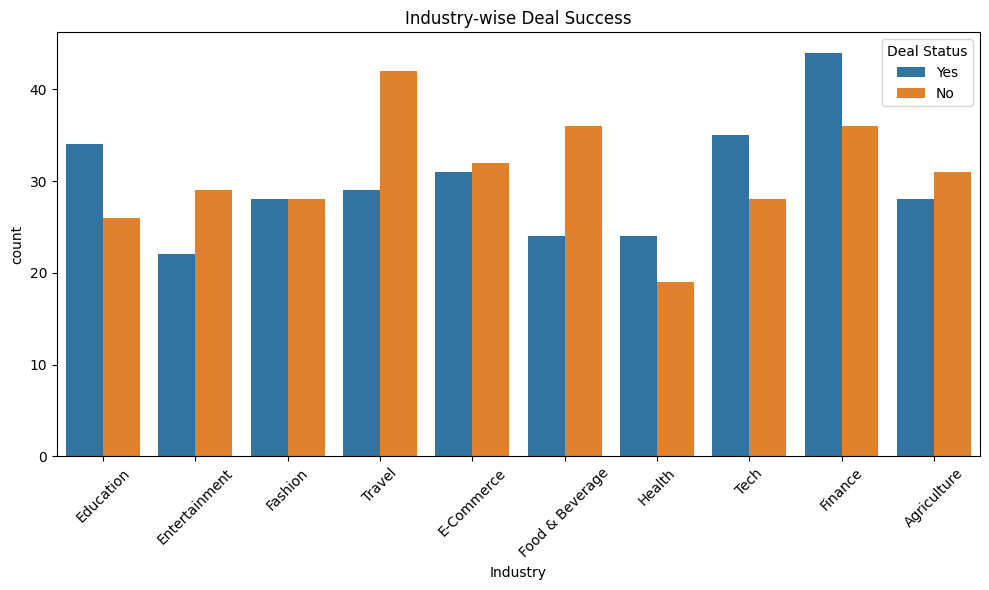

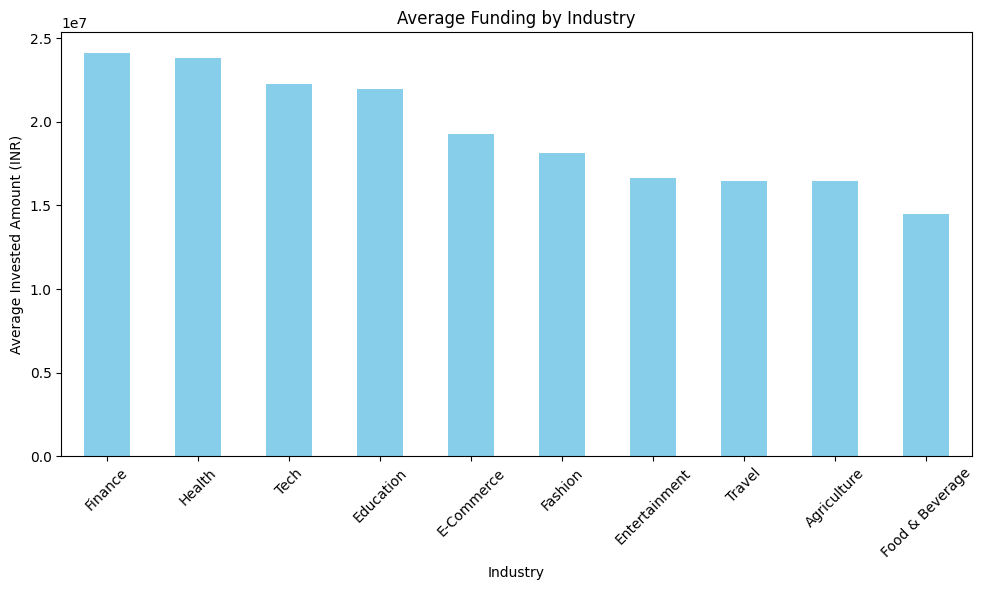

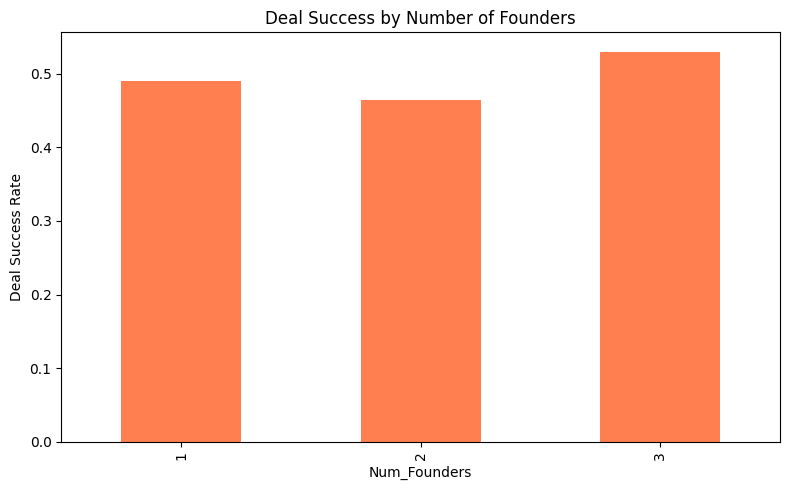

<Figure size 1000x600 with 0 Axes>

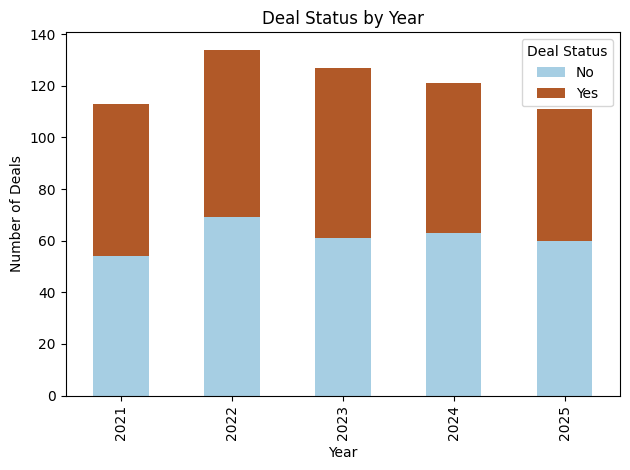

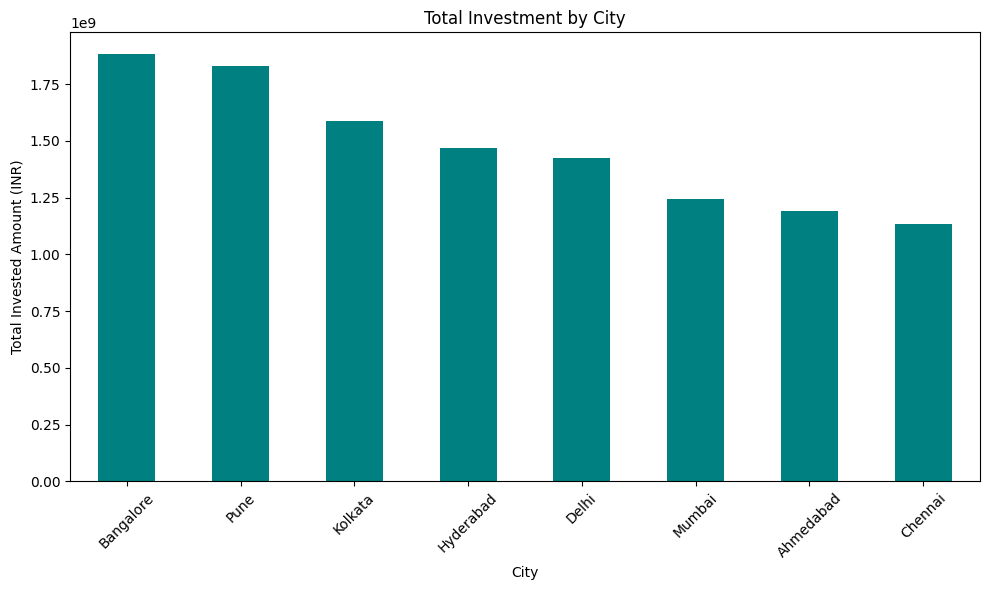

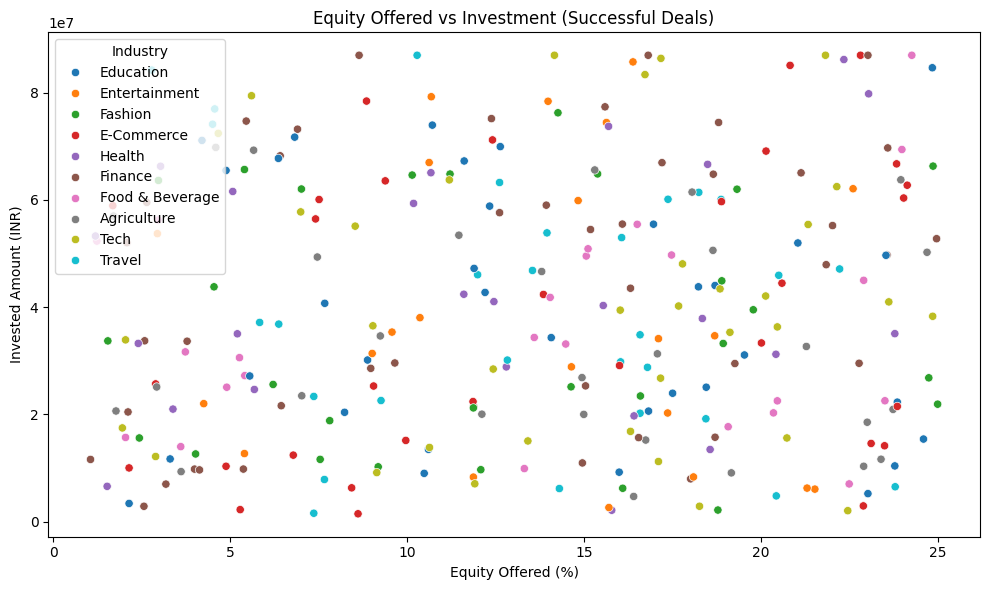

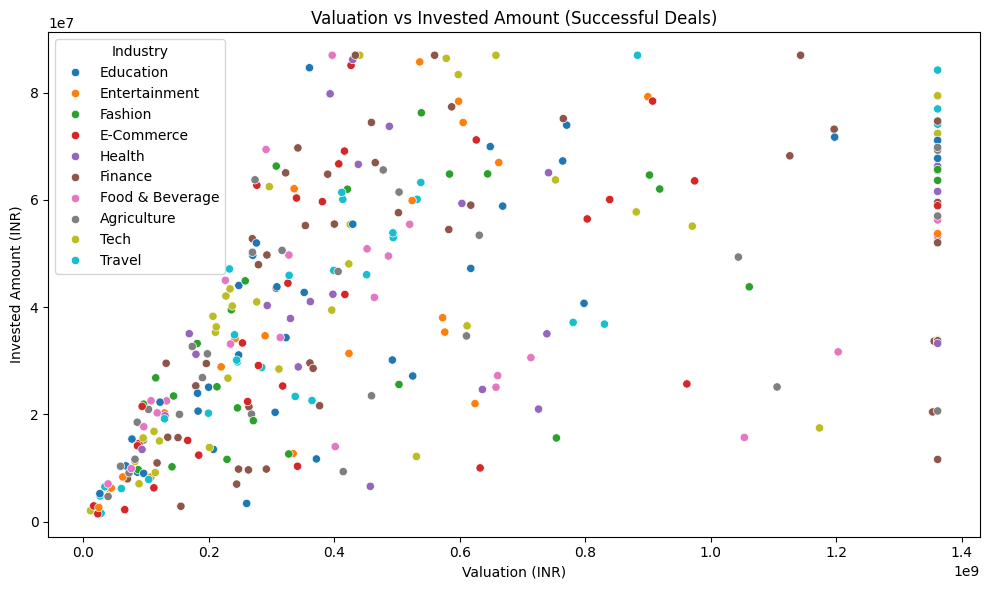

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Load the dataset
df = pd.read_csv("sharktank_startup_investment.csv")

# ----------------------
# 1. DATA CLEANING
# ----------------------
df['Investor(s)'] = df.apply(lambda row: row['Investor(s)'] if row['Deal Status'] == 'Yes' else 'No Deal', axis=1)
df['Investor(s)'] = df['Investor(s)'].fillna('Unknown')
df['Industry'] = df['Industry'].str.strip().str.title()
df['City'] = df['City'].str.strip().str.title()
df['Deal Status'] = df['Deal Status'].str.strip().str.title()
df.drop_duplicates(inplace=True)
print(df.isnull().sum())
print(df.info)
print(df.columns)

# ----------------------
# 2. FEATURE ENGINEERING
# ----------------------
df['Num_Founders'] = df['Founder(s)'].apply(lambda x: len(str(x).split(',')))
df['Funding Gap'] = df['Asked Amount (INR)'] - df['Invested Amount (INR)']
df['Funding % Fulfilled'] = df['Invested Amount (INR)'] / df['Asked Amount (INR)']
df['Deal_Success'] = df['Deal Status'].apply(lambda x: 1 if x == 'Yes' else 0)

# 3. OUTLIER HANDLING USING IQR
# ----------------------

# List of numeric columns to clean
num_cols = ['Asked Amount (INR)', 'Invested Amount (INR)', 'Valuation (INR)', 'Equity Offered (%)']

# Function to cap outliers using IQR
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df
# Apply to all target columns
for col in num_cols:
    df = cap_outliers_iqr(df, col)
# ----------------------
# 3. VISUALIZATION / EDA
# ----------------------

# Plot 1: Industry-wise Deal Status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Industry', hue='Deal Status')
plt.title("Industry-wise Deal Success")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("industry_success_count.png")
#files.download("industry_success_count.png")
plt.show()
plt.close()

# Plot 2: Average Invested Amount by Industry
industry_funding = df.groupby('Industry')['Invested Amount (INR)'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
industry_funding.plot(kind='bar', color='skyblue')
plt.ylabel("Average Invested Amount (INR)")
plt.title("Average Funding by Industry")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("avg_funding_by_industry.png")
#files.download("avg_funding_by_industry.png")
plt.show()
plt.close()

# Plot 3: Deal Success by Number of Founders
founders_success = df.groupby('Num_Founders')['Deal_Success'].mean()
plt.figure(figsize=(8, 5))
founders_success.plot(kind='bar', color='coral')
plt.ylabel("Deal Success Rate")
plt.title("Deal Success by Number of Founders")
plt.tight_layout()
plt.savefig("founder_success_rate.png")
#files.download("founder_success_rate.png")
plt.show()
plt.close()

# Plot 4: Deal Status by Year
yearly_deals = df.groupby(['Year', 'Deal Status']).size().unstack().fillna(0)
plt.figure(figsize=(10, 6))
yearly_deals.plot(kind='bar', stacked=True, colormap='Paired')
plt.title("Deal Status by Year")
plt.ylabel("Number of Deals")
plt.tight_layout()
plt.savefig("yearly_deal_status.png")
#files.download("yearly_deal_status.png")
plt.show()
plt.close()

# Plot 5: Total Invested Amount by City
city_funding = df.groupby('City')['Invested Amount (INR)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
city_funding.plot(kind='bar', color='teal')
plt.ylabel("Total Invested Amount (INR)")
plt.title("Total Investment by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("city_funding_total.png")
#files.download("city_funding_total.png")
plt.show()
plt.close()

# Plot 6: Equity Offered vs Invested Amount (Successful Deals)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['Deal_Success'] == 1],
                x='Equity Offered (%)',
                y='Invested Amount (INR)',
                hue='Industry')
plt.title("Equity Offered vs Investment (Successful Deals)")
plt.tight_layout()
plt.savefig("equity_vs_investment.png")
#files.download("equity_vs_investment.png")
plt.show()
plt.close()

# Plot 7: Valuation vs Invested Amount (Successful Deals)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['Deal_Success'] == 1],
                x='Valuation (INR)',
                y='Invested Amount (INR)',
                hue='Industry')
plt.title("Valuation vs Invested Amount (Successful Deals)")
plt.tight_layout()
plt.savefig("valuation_vs_investment.png")
#files.download("valuation_vs_investment.png")
plt.show()
plt.close()

# ----------------------
# 4. EXPORT CLEANED DATA
# ----------------------
df.to_csv("cleaned_sharktank_data.csv", index=False)
files.download("cleaned_sharktank_data.csv")
